In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.linear_model import CoxPHSurvivalAnalysis
from lifelines.statistics import proportional_hazard_test
from lifelines import CoxPHFitter
from tqdm import tqdm
from lifelines.utils.lowess import lowess

MAIN_DIR = "/home/joan/Desktop/PROJECTS/Glioblastomas/"

In [2]:
RESULTS = f"{MAIN_DIR}/RESULTS-GBM_5-cohorts_Spatial-components"
#RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_UMAP-Risks"
#RESULTS = f"{MAIN_DIR}/RESULTS-GBM_4-cohorts_TD-Tissues"

In [3]:
covariates_of_interest = [
    # Clinical
    "ID", "age", "sex", "eor", "mgmt", "kps (preop)", "OS (days)", "status",
    # Morphology
    'Whole tumor size (voxels)', 'Core size (voxels)', 'Non-enhancing size (voxels)', 'Enhancing size (voxels)',
    # Tract density
    'Whole TDMap', 'Whole lesion TDMap', #'Core TDMap', 'Core lesion TDMap', 'Non-enhancing TDMap', 'Non-enhancing lesion TDMap', 'Enhancing TDMap', 'Enhancing lesion TDMap', 'Core+Enhancing TDMap', 'Core+Enhancing lesion TDMap'
    # Network
    'size', 'density', 'avg_degree', 
    # Segregation-integration
    'avg_clustering', 'modularity', 'global_efficiency', 'avg_local_efficiency', 'avg_shortest_path_length', 'avg_participation_coef',
    # Centrality measures
    'avg_eigenvector_centrality', 'avg_betweenness_centrality', 'avg_closeness_centrality', 'avg_edge_betwenness_centrality','avg_percolation_centrality',
    # Topology
    'deg_assortativity', 'powerlaw_exponent', 'LLR_distribution', 's_metric_SF', 'avg_rich_club_coef',
]

daysXmonth = 365/12
daysXweek = 7
voxel_size = (0.5**3) * (1/1000) # 0.5 (mm³/voxel) X 0.001 (cm³/mm³)   

In [4]:
os.makedirs(f"{RESULTS}", exist_ok=True)
os.makedirs(f"{RESULTS}/OS-stats", exist_ok=True)

IDH = "WT"
STREAM_D_TH = 0
TISSUE = "whole"
MODE = "default"
GRADE = "IV"

LUMIERE = "Glioblastoma_LUMIERE-GBM_v1-13122022"
LUMIERE_TD = f"{MAIN_DIR}/{LUMIERE}/TDMaps_IDH1-{IDH}/demographics-TDMaps_streamTH-{STREAM_D_TH}.csv"
LUMIERE_MORPH = f"{MAIN_DIR}/{LUMIERE}/TDMaps_IDH1-{IDH}/morphology-tissues.csv"
LUMIERE_HCPEX = f"{MAIN_DIR}/{LUMIERE}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-HCPEx.csv"
LUMIERE_AAL3 = f"{MAIN_DIR}/{LUMIERE}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-AAL3.csv"

RHUH = "Glioblastoma_RHUH-GBM_v2-29102025"
RHUH_TD = f"{MAIN_DIR}/{RHUH}/TDMaps_IDH1-{IDH}/demographics-TDMaps_streamTH-{STREAM_D_TH}.csv"
RHUH_MORPH = f"{MAIN_DIR}/{RHUH}/TDMaps_IDH1-{IDH}/morphology-tissues.csv"
RHUH_HCPEX = f"{MAIN_DIR}/{RHUH}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-HCPEx.csv"
RHUH_AAL3 = f"{MAIN_DIR}/{RHUH}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-AAL3.csv"


TCGA = "Glioblastoma_TCGA-GBM_v1-20170717"
TCGA_TD = f"{MAIN_DIR}/{TCGA}/TDMaps_IDH1-{IDH}/demographics-TDMaps_streamTH-{STREAM_D_TH}.csv"
TCGA_MORPH = f"{MAIN_DIR}/{TCGA}/TDMaps_IDH1-{IDH}/morphology-tissues.csv"
TCGA_HCPEX = f"{MAIN_DIR}/{TCGA}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-HCPEx.csv"
TCGA_AAL3 = f"{MAIN_DIR}/{TCGA}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-AAL3.csv"


UCSF = "Glioblastoma_UCSF-PDGM_v3-20230111"
UCSF_TD = f"{MAIN_DIR}/{UCSF}/TDMaps_Grade-{GRADE}/demographics-TDMaps_streamTH-{STREAM_D_TH}.csv"
UCSF_MORPH = f"{MAIN_DIR}/{UCSF}/TDMaps_Grade-{GRADE}/morphology-tissues.csv"
UCSF_HCPEX = f"{MAIN_DIR}/{UCSF}/TDMaps_Grade-{GRADE}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-HCPEx.csv"
UCSF_AAL3 = f"{MAIN_DIR}/{UCSF}/TDMaps_Grade-{GRADE}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-AAL3.csv"


UPENN = "Glioblastoma_UPENN-GBM_v2-20221024"
UPENN_TD = f"{MAIN_DIR}/{UPENN}/TDMaps_IDH1-{IDH}/demographics-TDMaps_streamTH-{STREAM_D_TH}.csv"
UPENN_MORPH = f"{MAIN_DIR}/{UPENN}/TDMaps_IDH1-{IDH}/morphology-tissues.csv"
UPENN_HCPEX = f"{MAIN_DIR}/{UPENN}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-HCPEx.csv"
UPENN_AAL3 = f"{MAIN_DIR}/{UPENN}/TDMaps_IDH1-{IDH}/demographics-metrics_streamTH-{STREAM_D_TH}_tissue-{TISSUE}_connectome-{MODE}_atlas-AAL3.csv"

In [5]:
lumiere_td = pd.read_csv(LUMIERE_TD)
lumiere_morph = pd.read_csv(LUMIERE_MORPH)
lumiere_hcpex = pd.read_csv(LUMIERE_HCPEX)
lumiere_aal3 = pd.read_csv(LUMIERE_AAL3)

rhuh_td = pd.read_csv(RHUH_TD)
rhuh_morph = pd.read_csv(RHUH_MORPH)
rhuh_hcpex = pd.read_csv(RHUH_HCPEX)
rhuh_aal3 = pd.read_csv(RHUH_AAL3)

tcga_td = pd.read_csv(TCGA_TD)
tcga_morph = pd.read_csv(TCGA_MORPH)
tcga_hcpex = pd.read_csv(TCGA_HCPEX)
tcga_aal3 = pd.read_csv(TCGA_AAL3)

ucsf_td = pd.read_csv(UCSF_TD)
ucsf_morph = pd.read_csv(UCSF_MORPH)
ucsf_hcpex = pd.read_csv(UCSF_HCPEX)
ucsf_aal3 = pd.read_csv(UCSF_AAL3)

upenn_td = pd.read_csv(UPENN_TD)
upenn_morph = pd.read_csv(UPENN_MORPH)
upenn_hcpex = pd.read_csv(UPENN_HCPEX)
upenn_aal3 = pd.read_csv(UPENN_AAL3)

### LUMIERE processing

In [6]:
lumiere_td = lumiere_td.loc[lumiere_td['IDH (WT: wild type)'].str.upper()=='WT']
lumiere_td = lumiere_td.loc[lumiere_td['Survival time (weeks)']!='na']
lumiere_morph = lumiere_morph.loc[lumiere_morph['IDH (WT: wild type)'].str.upper()=='WT']
lumiere_morph = lumiere_morph.loc[lumiere_morph['Survival time (weeks)']!='na']
lumiere_hcpex = lumiere_hcpex.loc[lumiere_hcpex['IDH (WT: wild type)'].str.upper()=='WT']
lumiere_hcpex = lumiere_hcpex.loc[lumiere_hcpex['Survival time (weeks)']!='na']
lumiere_aal3 = lumiere_aal3.loc[lumiere_aal3['IDH (WT: wild type)'].str.upper()=='WT']
lumiere_aal3 = lumiere_aal3.loc[lumiere_aal3['Survival time (weeks)']!='na']

common_cols = [
    'Patient', 'Survival time (weeks)', 'Age at surgery (years)', 'Sex', 'IDH (WT: wild type)', 'MGMT qualitative'
]

lumiere = pd.merge(lumiere_td, lumiere_morph, on=common_cols)
merged_lumiere_hcpex = pd.merge(lumiere, lumiere_hcpex, on=common_cols)
merged_lumiere_aal3 = pd.merge(lumiere, lumiere_aal3, on=common_cols)

# All subjects in the LUMIERE cohort experienced an event
lumiere.insert(2, column='status', value=np.ones((len(lumiere), ), dtype=int))
merged_lumiere_hcpex.insert(2, column='status', value=np.ones((len(merged_lumiere_hcpex), ), dtype=int))
merged_lumiere_aal3.insert(2, column='status', value=np.ones((len(merged_lumiere_aal3), ), dtype=int))

print("HCPEx")
print(merged_lumiere_hcpex["status"].value_counts().sum())
censored = (merged_lumiere_hcpex["status"]==0).sum()
all_lumiere = merged_lumiere_hcpex["status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_lumiere,2)}%\n")

print("AAL3")
print(merged_lumiere_aal3["status"].value_counts().sum())
censored = (merged_lumiere_aal3["status"]==0).sum()
all_lumiere = merged_lumiere_aal3["status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_lumiere,2)}%")

HCPEx
54
Precentage of censoring: 0.0%

AAL3
54
Precentage of censoring: 0.0%


In [7]:
# We record survival in days to unify with the rest of the cohorts
merged_lumiere_hcpex["Survival time (weeks)"] = merged_lumiere_hcpex["Survival time (weeks)"].astype(int) * daysXweek
merged_lumiere_hcpex.rename(columns={"Survival time (weeks)": "Survival time (days)"}, inplace=True)

merged_lumiere_aal3["Survival time (weeks)"] = merged_lumiere_aal3["Survival time (weeks)"].astype(int) * daysXweek
merged_lumiere_aal3.rename(columns={"Survival time (weeks)": "Survival time (days)"}, inplace=True)

In [8]:
map_lumiere = {
    "Patient": "ID",
    'Age at surgery (years)': "age",
    "Sex": "sex",
    # "EOR": "eor", # For now we do not have EOR info but might be obtained later on from the preop and postop segmentations
    "MGMT qualitative": "mgmt",
    "Survival time (days)": "OS (days)"
}
for k,v in map_lumiere.items():
    merged_lumiere_hcpex.rename(columns={k: v}, inplace=True)
    merged_lumiere_aal3.rename(columns={k: v}, inplace=True)


# No EOR (for now) ---> fill with nans
merged_lumiere_hcpex["eor"] = np.nan
merged_lumiere_aal3["eor"] = np.nan

merged_lumiere_hcpex["kps (preop)"] = np.nan
merged_lumiere_aal3["kps (preop)"] = np.nan

In [9]:
map_sex = {"male": 0, "female": 1}
map_mgmt = {"not methylated": 0, "methylated": 2, "na": np.nan} # Intermediate methylation info is not available (though some percentages are rather low...)
# map_eor = {"biopsy": 0, "STR": 1, "GTR": 2, "Not Available": np.nan}

hcpex_lumiere = merged_lumiere_hcpex[covariates_of_interest].copy()
hcpex_lumiere["sex"] = hcpex_lumiere["sex"].map(map_sex)
hcpex_lumiere["mgmt"] = hcpex_lumiere["mgmt"].map(map_mgmt)

aal3_lumiere = merged_lumiere_aal3[covariates_of_interest].copy()
aal3_lumiere["sex"] = aal3_lumiere["sex"].map(map_sex)
aal3_lumiere["mgmt"] = aal3_lumiere["mgmt"].map(map_mgmt)

### RHUH processing

In [10]:
rhuh_td = rhuh_td.loc[rhuh_td['IDH status']=="wt"]
rhuh_td = rhuh_td.loc[rhuh_td['Previous treatment']=="no"]
rhuh_td = rhuh_td.loc[rhuh_td["Right Censored"].fillna('unknown')!='unknown']
rhuh_morph = rhuh_morph.loc[rhuh_morph['IDH status']=="wt"]
rhuh_morph = rhuh_morph.loc[rhuh_morph['Previous treatment']=="no"]
rhuh_morph = rhuh_morph.loc[rhuh_morph["Right Censored"].fillna('unknown')!='unknown']
rhuh_hcpex = rhuh_hcpex.loc[rhuh_hcpex['IDH status']=="wt"]
rhuh_hcpex = rhuh_hcpex.loc[rhuh_hcpex['Previous treatment']=="no"]
rhuh_hcpex = rhuh_hcpex.loc[rhuh_hcpex["Right Censored"].fillna('unknown')!='unknown']
rhuh_aal3 = rhuh_aal3.loc[rhuh_aal3['IDH status']=="wt"]
rhuh_aal3 = rhuh_aal3.loc[rhuh_aal3['Previous treatment']=="no"]
rhuh_aal3 = rhuh_aal3.loc[rhuh_aal3["Right Censored"].fillna('unknown')!='unknown']

common_cols = [
    'Patient ID', 'Days from earliest imaging to surgery', 'Age', 'Sex',
    'Preoperative KPS', 'Previous treatment', 'Histopathological subtype',
    'WHO grade', 'IDH status', 'Operative adjuncts',
    'Preoperative  contrast enhancing tumor volume (cm3)',
    'Postoperative contrast enhancing residual tumor (cm3)',
    'Preoperative T2/FLAIR abnormality  (cm3) ',
    'Postoperative T2/FLAIR abmnormality (cm3)',
    'Extent of resection [EOR]  %', 'EOR', 'Adjuvant therapy',
    'Radiotherapy treatment details (technique/dose/number of fractions)',
    'Postoperative Neurological Deficit', 'Postoperative KPS',
    'Progression free survival [PFS] (days)',
    'Overall survival [OS] (days)', 'Right Censored' 
]

rhuh = pd.merge(rhuh_td, rhuh_morph, on=common_cols)
merged_rhuh_hcpex = pd.merge(rhuh, rhuh_hcpex, on=common_cols)
merged_rhuh_aal3 = pd.merge(rhuh, rhuh_aal3, on=common_cols)

# Be careful with the definition of 'Right Censored' which is the opposite as 'Status' (Check the original reference in case of doubt)
merged_rhuh_hcpex.rename(columns={"Right Censored": "status"}, inplace=True)
merged_rhuh_hcpex["status"] = merged_rhuh_hcpex["status"].str.lower().map({"no": 1, "yes": 0})
merged_rhuh_aal3.rename(columns={"Right Censored": "status"}, inplace=True)
merged_rhuh_aal3["status"] = merged_rhuh_aal3["status"].str.lower().map({"no": 1, "yes": 0})

print("HCPEx")
print(merged_rhuh_hcpex["status"].value_counts().sum())
censored = (merged_rhuh_hcpex["status"]==0).sum()
all_rhuh = merged_rhuh_hcpex["status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_rhuh,2)}%\n")

print("AAL3")
print(merged_rhuh_aal3["status"].value_counts().sum())
censored = (merged_rhuh_aal3["status"]==0).sum()
all_rhuh = merged_rhuh_aal3["status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_rhuh,2)}%")

HCPEx
33
Precentage of censoring: 27.27%

AAL3
33
Precentage of censoring: 27.27%


In [11]:
# We unify the percentages of resection with the other datasets
mask = merged_rhuh_hcpex["Extent of resection [EOR]  %"] >= 90
merged_rhuh_hcpex.loc[mask, "EOR"] = "GTR"
merged_rhuh_hcpex.loc[~mask, "EOR"] = "STR"

mask = merged_rhuh_aal3["Extent of resection [EOR]  %"] >= 90
merged_rhuh_aal3.loc[mask, "EOR"] = "GTR"
merged_rhuh_aal3.loc[~mask, "EOR"] = "STR"

In [12]:
map_rhuh = {
    "Patient ID": "ID",
    "Age": "age",
    "Sex": "sex",
    "EOR": "eor",
    "Overall survival [OS] (days)": "OS (days)",
    "Preoperative KPS": "kps (preop)"
}
for k,v in map_rhuh.items():
    merged_rhuh_hcpex.rename(columns={k: v}, inplace=True)
    merged_rhuh_aal3.rename(columns={k: v}, inplace=True)


# No MGMT promoter status ---> fill with nans
merged_rhuh_hcpex["mgmt"] = np.nan
merged_rhuh_aal3["mgmt"] = np.nan

In [13]:
map_sex = {"male": 0, "female": 1}
map_eor = {"biopsy": 0, "STR": 1, "GTR": 2, "Not Available": np.nan}

hcpex_rhuh = merged_rhuh_hcpex[covariates_of_interest].copy()
hcpex_rhuh["sex"] = hcpex_rhuh["sex"].map(map_sex)
hcpex_rhuh["eor"] = hcpex_rhuh["eor"].map(map_eor)

aal3_rhuh = merged_rhuh_aal3[covariates_of_interest].copy()
aal3_rhuh["sex"] = aal3_rhuh["sex"].map(map_sex)
aal3_rhuh["eor"] = aal3_rhuh["eor"].map(map_eor)

### TCGA processing

In [14]:
tcga_td = tcga_td.loc[tcga_td['IDH.status']=="WT"]
tcga_morph = tcga_morph.loc[tcga_morph['IDH.status']=="WT"]
tcga_hcpex = tcga_hcpex.loc[tcga_hcpex['IDH.status']=="WT"]
tcga_aal3 = tcga_aal3.loc[tcga_aal3['IDH.status']=="WT"]

common_cols =  [
    'patient', 'Gender', 'Age..years.at.diagnosis.', 'Grade',
    'Survival..months.', 'Vital.status..1.dead.', 'IDH.status',
    'MGMT.promoter.status', 'Karnofsky.Performance.Score',
    'diagnosis.WHO2021', 'automatic.segmentation', 'manaul.correction'
]

tcga = pd.merge(tcga_td, tcga_morph, on=common_cols)
merged_tcga_hcpex = pd.merge(tcga, tcga_hcpex, on=common_cols)
merged_tcga_aal3 = pd.merge(tcga, tcga_aal3, on=common_cols)

print("HCPEx")
print(merged_tcga_hcpex["Vital.status..1.dead."].value_counts().sum())
censored = (merged_tcga_hcpex["Vital.status..1.dead."]==0).sum()
all_tcga = merged_tcga_hcpex["Vital.status..1.dead."].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_tcga,2)}%\n")

print("AAL3")
print(merged_tcga_aal3["Vital.status..1.dead."].value_counts().sum())
censored = (merged_tcga_aal3["Vital.status..1.dead."]==0).sum()
all_tcga = merged_tcga_aal3["Vital.status..1.dead."].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_tcga,2)}%")

HCPEx
103
Precentage of censoring: 20.39%

AAL3
103
Precentage of censoring: 20.39%


In [15]:
# We record survival in days to unify with the rest of the cohorts
merged_tcga_hcpex["Survival..months."] = merged_tcga_hcpex["Survival..months."] * daysXmonth
merged_tcga_hcpex.rename(columns={"Survival..months.": "Survival..days."}, inplace=True)

merged_tcga_aal3["Survival..months."] = merged_tcga_aal3["Survival..months."] * daysXmonth
merged_tcga_aal3.rename(columns={"Survival..months.": "Survival..days."}, inplace=True)

In [16]:
map_tcga = {
    "patient": "ID",
    "Age..years.at.diagnosis.": "age",
    "Gender": "sex",
    "MGMT.promoter.status": "mgmt",
    "Survival..days.": "OS (days)",
    "Vital.status..1.dead.": "status",
    "Karnofsky.Performance.Score": "kps (preop)"
}
for k,v in map_tcga.items():
    merged_tcga_hcpex.rename(columns={k: v}, inplace=True)
    merged_tcga_aal3.rename(columns={k: v}, inplace=True)

merged_tcga_hcpex["eor"] = np.nan
merged_tcga_aal3["eor"] = np.nan

In [17]:
map_sex = {"male": 0, "female": 1}
map_mgmt = {"Unmethylated": 0, "Indeterminate": 1, "Methylated": 2, "Not Available": np.nan}

hcpex_tcga = merged_tcga_hcpex[covariates_of_interest].copy()
hcpex_tcga["sex"] = hcpex_tcga["sex"].map(map_sex)
hcpex_tcga["mgmt"] = hcpex_tcga["mgmt"].map(map_mgmt)

aal3_tcga = merged_tcga_aal3[covariates_of_interest].copy()
aal3_tcga["sex"] = aal3_tcga["sex"].map(map_sex)
aal3_tcga["mgmt"] = aal3_tcga["mgmt"].map(map_mgmt)

### UCSF processing

In [18]:
ucsf_td = ucsf_td.loc[ucsf_td["Final pathologic diagnosis (WHO 2021)"]=="Glioblastoma  IDH-wildtype"] 
ucsf_td = ucsf_td.loc[ucsf_td["OS"].fillna('unknown')!='unknown']
ucsf_morph = ucsf_morph.loc[ucsf_morph["Final pathologic diagnosis (WHO 2021)"]=="Glioblastoma  IDH-wildtype"] 
ucsf_morph = ucsf_morph.loc[ucsf_morph["OS"].fillna('unknown')!='unknown']
ucsf_hcpex = ucsf_hcpex.loc[ucsf_hcpex["Final pathologic diagnosis (WHO 2021)"]=="Glioblastoma  IDH-wildtype"] 
ucsf_hcpex = ucsf_hcpex.loc[ucsf_hcpex["OS"].fillna('unknown')!='unknown']
ucsf_aal3 = ucsf_aal3.loc[ucsf_aal3["Final pathologic diagnosis (WHO 2021)"]=="Glioblastoma  IDH-wildtype"] 
ucsf_aal3 = ucsf_aal3.loc[ucsf_aal3["OS"].fillna('unknown')!='unknown']

common_cols = ['ID', 'Sex', 'Age at MRI', 'WHO CNS Grade', 
       'Final pathologic diagnosis (WHO 2021)', 'MGMT status', 'MGMT index',
       '1p/19q', 'IDH', '1-dead 0-alive', 'OS', 'EOR',
       'Biopsy prior to imaging', 'BraTS21 ID', 'BraTS21 Segmentation Cohort',
       'BraTS21 MGMT Cohort','# Labels'
]
ucsf = pd.merge(ucsf_td, ucsf_morph, on=common_cols)
merged_ucsf_hcpex = pd.merge(ucsf, ucsf_hcpex, on=common_cols)
merged_ucsf_aal3 = pd.merge(ucsf, ucsf_aal3, on=common_cols)

print("HCPEx")
print(merged_ucsf_hcpex["1-dead 0-alive"].value_counts().sum())
censored = (merged_ucsf_hcpex["1-dead 0-alive"]==0).sum()
all_ucsf = merged_ucsf_hcpex["1-dead 0-alive"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_ucsf,2)}%\n")

print("AAL3")
print(merged_ucsf_aal3["1-dead 0-alive"].value_counts().sum())
censored = (merged_ucsf_aal3["1-dead 0-alive"]==0).sum()
all_ucsf = merged_ucsf_aal3["1-dead 0-alive"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_ucsf,2)}%")

HCPEx
367
Precentage of censoring: 39.24%

AAL3
367
Precentage of censoring: 39.24%


In [19]:
map_ucsf = {
    "Age at MRI": "age",
    "Sex": "sex",
    "MGMT status": "mgmt",
    "EOR": "eor",
    "OS": "OS (days)",
    "1-dead 0-alive": "status"
}
for k,v in map_ucsf.items():
    merged_ucsf_hcpex.rename(columns={k: v}, inplace=True)
    merged_ucsf_aal3.rename(columns={k: v}, inplace=True)

merged_ucsf_hcpex["kps (preop)"] = np.nan
merged_ucsf_aal3["kps (preop)"] = np.nan

In [20]:
map_sex = {"M": 0, "F": 1}
map_mgmt = {"negative": 0, "indeterminate": 1, "positive": 2, "Not Available": np.nan}
map_eor = {"biopsy": 0, "STR": 1, "GTR": 2, "Not Available": np.nan}

hcpex_ucsf = merged_ucsf_hcpex[covariates_of_interest].copy()
hcpex_ucsf["sex"] = hcpex_ucsf["sex"].map(map_sex)
hcpex_ucsf["eor"] = hcpex_ucsf["eor"].map(map_eor)
hcpex_ucsf["mgmt"] = hcpex_ucsf["mgmt"].map(map_mgmt)

aal3_ucsf = merged_ucsf_aal3[covariates_of_interest].copy()
aal3_ucsf["sex"] = aal3_ucsf["sex"].map(map_sex)
aal3_ucsf["eor"] = aal3_ucsf["eor"].map(map_eor)
aal3_ucsf["mgmt"] = aal3_ucsf["mgmt"].map(map_mgmt)

### UPENN processing

In [21]:
common_cols = [
    "ID", "Gender", "Age_at_scan_years", 
    "Survival_from_surgery_days_UPDATED", "Survival_Status", 
    "MGMT", "KPS", "GTR_over90percent"
]
upenn = pd.merge(upenn_td, upenn_morph, on=common_cols)
merged_upenn_hcpex = pd.merge(upenn, upenn_hcpex, on=common_cols)
merged_upenn_aal3 = pd.merge(upenn, upenn_aal3, on=common_cols)

print("HCPEx")
print(merged_upenn_hcpex["Survival_Status"].value_counts().sum())
censored = (merged_upenn_hcpex["Survival_Status"]==0).sum()
all_upenn = merged_upenn_hcpex["Survival_Status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_upenn,2)}%\n")

print("AAL3")
print(merged_upenn_aal3["Survival_Status"].value_counts().sum())
censored = (merged_upenn_aal3["Survival_Status"]==0).sum()
all_upenn = merged_upenn_aal3["Survival_Status"].value_counts().sum()
print(f"Precentage of censoring: {round(100*censored/all_upenn,2)}%\n")

HCPEx
496
Precentage of censoring: 2.82%

AAL3
496
Precentage of censoring: 2.82%



In [22]:
map_upenn = {
    "Age_at_scan_years": "age",
    "Gender": "sex",
    "MGMT": "mgmt",
    "GTR_over90percent": "eor",
    "Survival_from_surgery_days_UPDATED": "OS (days)",
    "Survival_Status": "status",
    "KPS": "kps (preop)"
}
for k,v in map_upenn.items():
    merged_upenn_hcpex.rename(columns={k: v}, inplace=True)
    merged_upenn_aal3.rename(columns={k: v}, inplace=True)

In [23]:
map_sex = {"M": 0, "F": 1}
map_mgmt = {"Unmethylated": 0, "Indeterminate": 1, "Methylated": 2, "Not Available": np.nan}
map_eor = {"N": 1, "Y": 2, "Not Available": np.nan}

hcpex_upenn = merged_upenn_hcpex[covariates_of_interest].copy()
hcpex_upenn["sex"] = hcpex_upenn["sex"].map(map_sex)
hcpex_upenn["eor"] = hcpex_upenn["eor"].map(map_eor)
hcpex_upenn["mgmt"] = hcpex_upenn["mgmt"].map(map_mgmt)
hcpex_upenn["kps (preop)"] = hcpex_upenn["kps (preop)"].replace("Not Available", np.nan)

aal3_upenn = merged_upenn_aal3[covariates_of_interest].copy()
aal3_upenn["sex"] = aal3_upenn["sex"].map(map_sex)
aal3_upenn["eor"] = aal3_upenn["eor"].map(map_eor)
aal3_upenn["mgmt"] = aal3_upenn["mgmt"].map(map_mgmt)
aal3_upenn["kps (preop)"] = aal3_upenn["kps (preop)"].replace("Not Available", np.nan)

### Merging all cohorts

In [24]:
hcpex_ucsf["cohort"] = 0
hcpex_upenn["cohort"] = 1
hcpex_tcga["cohort"] = 2
hcpex_rhuh["cohort"] = 3
hcpex_lumiere["cohort"] = 4
# Related to how survival was recorded
hcpex_ucsf["site"] = 0
hcpex_upenn["site"] = 1
hcpex_tcga["site"] = 1
hcpex_rhuh["site"] = 1
hcpex_lumiere["site"] = 1 # temporary

hcpex = pd.concat(
    (hcpex_ucsf, hcpex_upenn, hcpex_tcga, hcpex_rhuh, hcpex_lumiere), 
    ignore_index=True
)

aal3_ucsf["cohort"] = 0
aal3_upenn["cohort"] = 1
aal3_tcga["cohort"] = 2
aal3_rhuh["cohort"] = 3
aal3_lumiere["cohort"] = 4
# Related to how survival was recorded
aal3_ucsf["site"] = 0
aal3_upenn["site"] = 1
aal3_tcga["site"] = 1
aal3_rhuh["site"] = 1
aal3_lumiere["site"] = 1 # temporary

aal3 = pd.concat(
    (aal3_ucsf, aal3_upenn, aal3_tcga, aal3_rhuh, aal3_lumiere), 
    ignore_index=True
)

all_cohorts = {0: all_ucsf, 1:all_upenn, 2:all_tcga,  3:all_rhuh,  4:all_lumiere}

In [25]:
hcpex.tail()

,ID,age,sex,eor,mgmt,kps (preop),OS (days),status,Whole tumor size (voxels),Core size (voxels),...,avg_closeness_centrality,avg_edge_betwenness_centrality,avg_percolation_centrality,deg_assortativity,powerlaw_exponent,LLR_distribution,s_metric_SF,avg_rich_club_coef,cohort,site
1048,LUMIERE-088,73.0,0,NaN,0.0,NaN,406.0,1.0,957705.0,308127.0,...,0.519694,0.000156,0.002429,-0.363285,2.187755,-40.926765,188909749.0,0.818061,4,1
1049,LUMIERE-089,57.0,1,NaN,2.0,NaN,574.0,1.0,1545389.0,154434.0,...,0.547056,0.000118,0.002102,-0.315541,2.657041,-36.087164,262255307.0,0.808970,4,1
1050,LUMIERE-090,74.0,1,NaN,0.0,NaN,350.0,1.0,487039.0,16716.0,...,0.561539,0.000088,0.001962,-0.154115,2.728993,-55.558945,360818027.0,0.707031,4,1
1051,LUMIERE-086,63.0,1,NaN,2.0,NaN,1197.0,1.0,1850380.0,550008.0,...,0.550077,0.000108,0.002076,-0.320148,2.250824,-54.145297,326475779.0,0.794582,4,1
1052,LUMIERE-091,63.0,0,NaN,NaN,NaN,434.0,1.0,1156883.0,794680.0,...,0.535274,0.000128,0.002272,-0.350081,2.424525,-35.024678,257369601.0,0.781528,4,1


### Correcting for survival recording types

ATENTION!!
------>	 Cohorts UCSF and UPENN: chi-squared of 12.4779 with p-value of 0.0004 (two-sided log-rank test)
ATENTION!!
------>	 Cohorts UCSF and TCGA: chi-squared of 7.0899 with p-value of 0.0078 (two-sided log-rank test)
Cohorts UCSF and RHUH: chi-squared of 1.8542 with p-value of 0.1733 (two-sided log-rank test)
Cohorts UCSF and LUMIERE: chi-squared of 2.3654 with p-value of 0.1241 (two-sided log-rank test)
Cohorts UPENN and TCGA: chi-squared of 0.1846 with p-value of 0.6674 (two-sided log-rank test)
Cohorts UPENN and RHUH: chi-squared of 0.0021 with p-value of 0.9634 (two-sided log-rank test)
Cohorts UPENN and LUMIERE: chi-squared of 0.0821 with p-value of 0.7745 (two-sided log-rank test)
Cohorts TCGA and RHUH: chi-squared of 0.0393 with p-value of 0.8428 (two-sided log-rank test)
Cohorts TCGA and LUMIERE: chi-squared of 0.4117 with p-value of 0.5211 (two-sided log-rank test)
Cohorts RHUH and LUMIERE: chi-squared of 0.7707 with p-value of 0.38 (two-sided log-rank test)


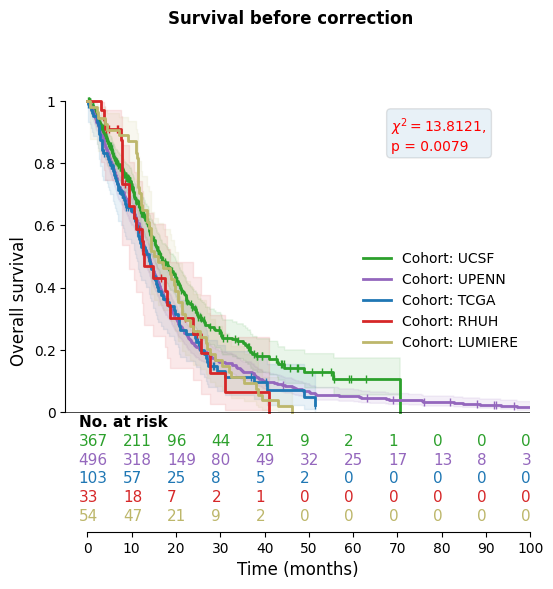

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

months = range(0,110,10)
cohort_ids = [0,1,2,3,4]
colors = ["tab:green", "tab:purple", "tab:blue","tab:red", "darkkhaki"]
cohort_name = ["UCSF", "UPENN", "TCGA", "RHUH", "LUMIERE"]
name_cohort = {k:v for k,v in zip(cohort_ids, cohort_name)}
OS_STATS_deSITE = []
GROUP_STATS = []

nums = np.empty(shape=(len(cohort_ids),), dtype=object)
for i, cohort in enumerate(cohort_ids):
    diag = hcpex[hcpex["cohort"]==cohort]
    mask = ~np.isnan(diag["status"]) & ~np.isnan(diag["OS (days)"])
    diag = diag[mask]

    nums[i] = []
    for t in months:
        nums[i].append((diag["OS (days)"]>=(t*daysXmonth)).sum())
    
    time, survival_prob, conf_int = kaplan_meier_estimator(
                diag["status"]==1, diag["OS (days)"], conf_type="log-log"
            )
    time = np.insert(time, 0, 0)
    survival_prob = np.insert(survival_prob, 0, 1)
    conf_int = np.insert(conf_int, 0, 1, axis=1)
    ax.step(time/daysXmonth, survival_prob, where="post", color=colors[i], label=f"Cohort: {cohort_name[i]}", linewidth=2)
    ax.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.10, step="post", color=colors[i])
    for t in diag.loc[diag["status"]==0, "OS (days)"].values: # Censoring times
        ax.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color=colors[i])

    OS_STATS_deSITE.extend([(st, ovs) for st, ovs in zip(diag["status"]==1, diag["OS (days)"].values)])
    GROUP_STATS.extend([i+1 for ovs in diag["OS (days)"].values])

OS_STATS_deSITE = np.array(OS_STATS_deSITE, dtype=[('event', 'bool'),('time', 'float')])
chisquared, p_val, stats, covariance = compare_survival(OS_STATS_deSITE, GROUP_STATS, return_stats=True)
ax.text(0.70, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")    

for i,t in enumerate(months):
    ax.text(t-2, -0.07, f"{nums[0][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[0]) 
    ax.text(t-2, -0.13, f"{nums[1][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[1]) 
    ax.text(t-2, -0.19, f"{nums[2][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[2]) 
    ax.text(t-2, -0.25, f"{nums[3][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[3])  
    ax.text(t-2, -0.31, f"{nums[4][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[4]) 
ax.text(-2, -0.01, "No. at risk", transform=ax.transData, fontsize=11, verticalalignment='top', color="black", fontweight='bold') 
ax.hlines(0,-5,months[-1]+5, color="black", linewidth=.5)
ax.set_ylim([-.385,1.1])
ax.set_xlim([-5,75])
ax.set_xticks(range(0,months[-1]+10,10))
ax.set_xticklabels(range(0,months[-1]+10,10))
ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
ax.spines['left'].set_bounds(0,1)
ax.spines['bottom'].set_bounds(0,months[-1])
ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Overall survival", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.suptitle("Survival before correction", fontweight="bold")
fig.savefig(f"{RESULTS}/OS-stats/OS-cohorts_before-correction.pdf", dpi=200, format="pdf")
fig.savefig(f"{RESULTS}/OS-stats/OS-cohorts_before-correction.svg", dpi=200, format="svg")

GROUP_STATS_array = np.array(GROUP_STATS)
chisquared, p_val = np.zeros((len(cohort_ids), len(cohort_ids))), np.zeros((len(cohort_ids), len(cohort_ids)))

for i, cohort_i in enumerate(cohort_ids):
    for j in range(i+1, len(cohort_ids)):
        cohort_j = cohort_ids[j]

        chisquared[i,j], p_val[i,j] = compare_survival(
            OS_STATS_deSITE[(GROUP_STATS_array==cohort_i+1) | (GROUP_STATS_array==cohort_j+1)], 
            list(GROUP_STATS_array[(GROUP_STATS_array==cohort_i+1) | (GROUP_STATS_array==cohort_j+1)]), 
            return_stats=False
        )
        if p_val[i,j]<=0.05:
            print(f"ATENTION!!\n------>\t Cohorts {name_cohort[i]} and {name_cohort[j]}: chi-squared of {chisquared[i,j].round(4)} with p-value of {p_val[i,j].round(4)} (two-sided log-rank test)")
        else: 
            print(f"Cohorts {name_cohort[i]} and {name_cohort[j]}: chi-squared of {chisquared[i,j].round(4)} with p-value of {p_val[i,j].round(4)} (two-sided log-rank test)")


In [27]:
def inspect_survival_diffs_in_paired_cohorts(full_data, cohorts, RESULTS, name_cohort, duration_col="OS (days)", status_col="status", daysXmonth=365/12, months=range(0,110,10), n_perms=1000, eps_=0.01, show_plot=True):

    cohorts = sorted(cohorts)
    
    print("+"*40)
    print(f"{name_cohort[cohorts[0]]} vs. {name_cohort[cohorts[1]]}")

    # Pre-correction
    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1]) 
    ax1 = plt.subplot(gs[0, 0]) 
    ax2 = plt.subplot(gs[:, 1])
    ax3 = plt.subplot(gs[1, 0])
    OS_STATS = []
    GROUP_STATS = []
    nums = np.empty(shape=(2,), dtype=object)
    for i, cohort in enumerate(cohorts):
        diag = full_data[full_data["cohort"]==cohort]
        mask = ~np.isnan(diag[status_col]) & ~np.isnan(diag[duration_col])
        diag = diag[mask]
        nums[i] = []
        for t in months:
            nums[i].append((diag[duration_col]>=(t*daysXmonth)).sum())
        time, survival_prob, conf_int = kaplan_meier_estimator(
                    diag[status_col]==1, diag[duration_col], conf_type="log-log"
                )
        time = np.insert(time, 0, 0)
        survival_prob = np.insert(survival_prob, 0, 1)
        conf_int = np.insert(conf_int, 0, 1, axis=1)
        ax1.step(np.log(eps_+time/daysXmonth), np.log(eps_-np.log(eps_+survival_prob)), where="post", label=f"Cohort: {name_cohort[cohort]} (n={all_cohorts[cohort]})" if cohort==cohorts[0] else f"Cohort: {name_cohort[cohort]} (N={all_cohorts[cohort]})", color=colors[cohort])
        ax1.fill_between(np.log(eps_+time/daysXmonth), np.log(eps_-np.log(eps_+conf_int[0])), np.log(eps_-np.log(eps_+conf_int[1])), alpha=0.15, step="post", color=colors[cohort])
        for t in diag.loc[diag[status_col]==0, duration_col].values: # Censoring times
            ax1.plot(np.log(eps_+time[time==t]/daysXmonth), np.log(eps_-np.log(eps_+survival_prob[time==t])), "|", color=colors[cohort])
        OS_STATS.extend([(st, ovs) for st, ovs in zip(diag[status_col]==1, diag[duration_col].values)])
        GROUP_STATS.extend([i+1 for ovs in diag[duration_col].values])
    OS_STATS = np.array(OS_STATS, dtype=[('event', 'bool'),('time', 'float')])
    chisquared, p_val, stats, covariance = compare_survival(OS_STATS, GROUP_STATS, return_stats=True)
    ax1.text(0.05, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax1.transAxes, 
                        fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")        
    ax1.set_xlabel("log [ time ]", fontsize=12)
    ax1.set_ylabel("log [ -log [ Survival ] ]", fontsize=12)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.legend(frameon=False)

    # Fit the model to estimate the site-effect ---> the covariates should be {0,1} not directly the cohort IDs
    map4cox = {cohorts[0]:0, cohorts[1]:1}
    Cmodel = CoxPHSurvivalAnalysis(n_iter=200)
    mask = ~np.isnan(full_data[status_col]) & ~np.isnan(full_data[duration_col]) & ((full_data["cohort"] == cohorts[0]) | (full_data["cohort"] == cohorts[1]))
    Cmodel.fit(full_data.loc[mask, "cohort"].map(map4cox).values.reshape(-1,1), OS_STATS)
    c_index = Cmodel.score(full_data.loc[mask, "cohort"].map(map4cox).values.reshape(-1,1), OS_STATS)
    pop = []
    for perm_i in tqdm(range(n_perms)):#
        perm_OS_STATS = np.random.permutation(OS_STATS)
        p_Cmodel = CoxPHSurvivalAnalysis()
        p_Cmodel.fit(full_data.loc[mask, "cohort"].map(map4cox).values.reshape(-1, 1), perm_OS_STATS)
        pop.append(p_Cmodel.score(full_data.loc[mask, "cohort"].map(map4cox).values.reshape(-1, 1), perm_OS_STATS))
    p_value = np.mean(np.array(pop) >= c_index)
    print(f"C-index = {c_index} (p={p_value})")
    print(f"Log HR = {Cmodel.coef_}")

    # Plot Schoenfeld residuals
    lifelines_model = CoxPHFitter()
    data = full_data[["cohort", duration_col, status_col]].dropna()
    data = data[(data["cohort"]==cohorts[0])|(data["cohort"]==cohorts[1])]
    lifelines_model.fit(data, duration_col=duration_col, event_col=status_col)
    test = proportional_hazard_test(lifelines_model, data, time_transform="all") #Grambsch-Therneau Test
    print("\nResults form the Grambsch-Therneau test:")
    print(test.summary)
    rank_stat, p_val_GT = test.test_statistic[0], test.p_value[0]
    schoenfeld_residuals = lifelines_model.compute_residuals(data, kind='scaled_schoenfeld')
    site_schoenfeld_residuals = schoenfeld_residuals['cohort'].values
    tt = data.loc[data['status']==1, 'OS (days)'].rank()
    ax3.scatter(tt[site_schoenfeld_residuals>0], site_schoenfeld_residuals[site_schoenfeld_residuals>0], color=colors[cohorts[1]], alpha=0.25)
    ax3.scatter(tt[site_schoenfeld_residuals<0], site_schoenfeld_residuals[site_schoenfeld_residuals<0], color=colors[cohorts[0]], alpha=0.25)
    y_lowess = lowess(tt.values, site_schoenfeld_residuals)
    ax3.scatter(tt.values, y_lowess, color="k", alpha=1.0, s=1)
    for _ in range(10):
        ix = sorted(np.random.choice(tt.shape[0], tt.shape[0]))
        tt_ = tt.values[ix]
        y_lowess = lowess(tt_, site_schoenfeld_residuals[ix])
        ax3.scatter(tt_, y_lowess, color="gray", alpha=0.10, s=2, marker="+")
    ax3.set_xlabel(f"rank-transformed time\n(GT={rank_stat:.4f}; p={p_val_GT:.4f})", fontsize=8)
    ax3.set_ylabel("scaled-Schoenfeld Residuals", fontsize=10)
    ax3.spines[["top", "right"]].set_visible(False)

    # Post-correction
    OS_STATS_deSITE = []
    GROUP_STATS = []
    nums = np.empty(shape=(2,), dtype=object)
    for i, cohort in enumerate(cohorts):
        diag = full_data[full_data["cohort"]==cohort]
        mask = ~np.isnan(diag[status_col]) & ~np.isnan(diag[duration_col])
        diag = diag[mask]
        diag[duration_col] = diag[duration_col] * np.exp(Cmodel.coef_[0]*i) #* np.exp(Cmodel.coef_[0]*cohort)
        nums[i] = []
        for t in months:
            nums[i].append((diag[duration_col]>=(t*daysXmonth)).sum())
        
        time, survival_prob, conf_int = kaplan_meier_estimator(
                    diag[status_col]==1, diag[duration_col], conf_type="log-log"
                )
        time = np.insert(time, 0, 0)
        survival_prob = np.insert(survival_prob, 0, 1)
        conf_int = np.insert(conf_int, 0, 1, axis=1)
        ax2.step(time/daysXmonth, survival_prob, where="post", color=colors[cohort])
        ax2.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.15, step="post", color=colors[cohort])
        for t in diag.loc[diag[status_col]==0, duration_col].values: # Censoring times
            ax2.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color=colors[cohort])

        OS_STATS_deSITE.extend([(st, ovs) for st, ovs in zip(diag[status_col]==1, diag[duration_col].values)])
        GROUP_STATS.extend([i+1 for ovs in diag[duration_col].values])

    OS_STATS_deSITE = np.array(OS_STATS_deSITE, dtype=[('event', 'bool'),('time', 'float')])
    chisquared, p_val, stats, covariance = compare_survival(OS_STATS_deSITE, GROUP_STATS, return_stats=True)
    ax2.text(0.70, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax2.transAxes, 
                        fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")        

    # Plotting the uncorrected data
    diag = full_data[full_data["cohort"]==cohorts[1]]
    mask = ~np.isnan(diag[status_col]) & ~np.isnan(diag[duration_col])
    diag = diag[mask]
    for t in months:
        nums[i].append((diag[duration_col]>=(t*daysXmonth)).sum())
    time, survival_prob, conf_int = kaplan_meier_estimator(
                diag[status_col]==1, diag[duration_col], conf_type="log-log"
            )
    ax2.step(time/daysXmonth, survival_prob, where="post", color="gray", alpha=0.5, label=f"{name_cohort[cohorts[1]]} uncorrected")
    ax2.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.15, step="post", color="gray")
    for t in diag.loc[diag[status_col]==0, duration_col].values: # Censoring times
        ax2.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color="gray")

    for i,t in enumerate(months):
        ax2.text(t-2, -0.07, f"{nums[0][i]}", transform=ax2.transData, fontsize=11, verticalalignment='top', color=colors[cohorts[0]]) 
        ax2.text(t-2, -0.13, f"{nums[1][i]}", transform=ax2.transData, fontsize=11, verticalalignment='top', color=colors[cohorts[1]]) 
    ax2.text(-2, -0.01, "No. at risk", transform=ax2.transData, fontsize=11, verticalalignment='top', color="black", fontweight='bold') 
    ax2.hlines(0,-5,months[-1]+5, color="black", linewidth=.5)
    ax2.set_ylim([-.2,1])
    ax2.set_xlim([-5,75])
    ax2.set_xticks(range(0,months[-1]+10,10))
    ax2.set_xticklabels(range(0,months[-1]+10,10))
    ax2.set_yticks([0,0.2,0.4,0.6,0.8,1])
    ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
    ax2.spines['left'].set_bounds(0,1)
    ax2.spines['bottom'].set_bounds(0,months[-1])
    ax2.set_xlabel("Time (months)", fontsize=12)
    ax2.set_ylabel("Overall survival", fontsize=12)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.legend(frameon=False)

    fig.suptitle(f"{name_cohort[cohorts[0]]} vs. {name_cohort[cohorts[1]]}", fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{RESULTS}/OS-stats/Site-effects_Survival-times_{name_cohort[cohorts[0]]}-{name_cohort[cohorts[1]]}.pdf", dpi=200, format="pdf")
    fig.savefig(f"{RESULTS}/OS-stats/Site-effects_Survival-times_{name_cohort[cohorts[0]]}-{name_cohort[cohorts[1]]}.svg", dpi=200, format="svg")
    if show_plot:
        plt.show()
    else:
        plt.close()

    print("+"*40)

++++++++++++++++++++++++++++++++++++++++
UCSF vs. UPENN


  1%|▏         | 13/1000 [00:00<00:27, 36.24it/s]

100%|██████████| 1000/1000 [00:31<00:00, 31.63it/s]


C-index = 0.5342924496048814 (p=0.002)
Log HR = [0.28700473]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        0.119648  0.729417  0.455185
       km              0.034053  0.853594  0.228378
       log             0.123463  0.725308  0.463333
       rank            0.021137  0.884407  0.177218


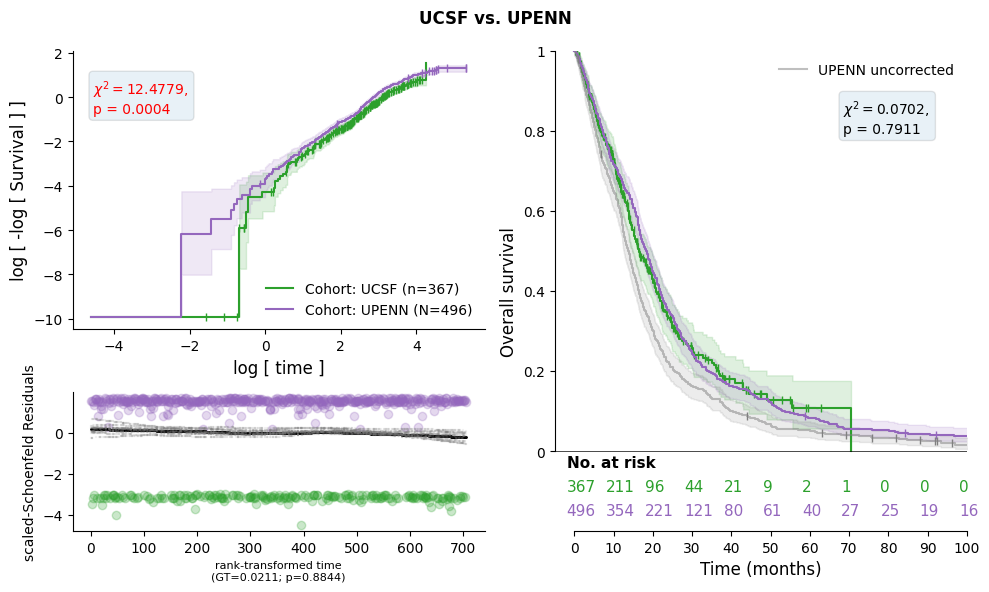

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UCSF vs. TCGA


100%|██████████| 1000/1000 [00:16<00:00, 60.16it/s]


C-index = 0.5303581938380257 (p=0.024)
Log HR = [0.34275387]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        0.174496  0.676146  0.564593
       km              0.068576  0.793421  0.333841
       log             0.009887  0.920795  0.119049
       rank            0.040669  0.840178  0.251233


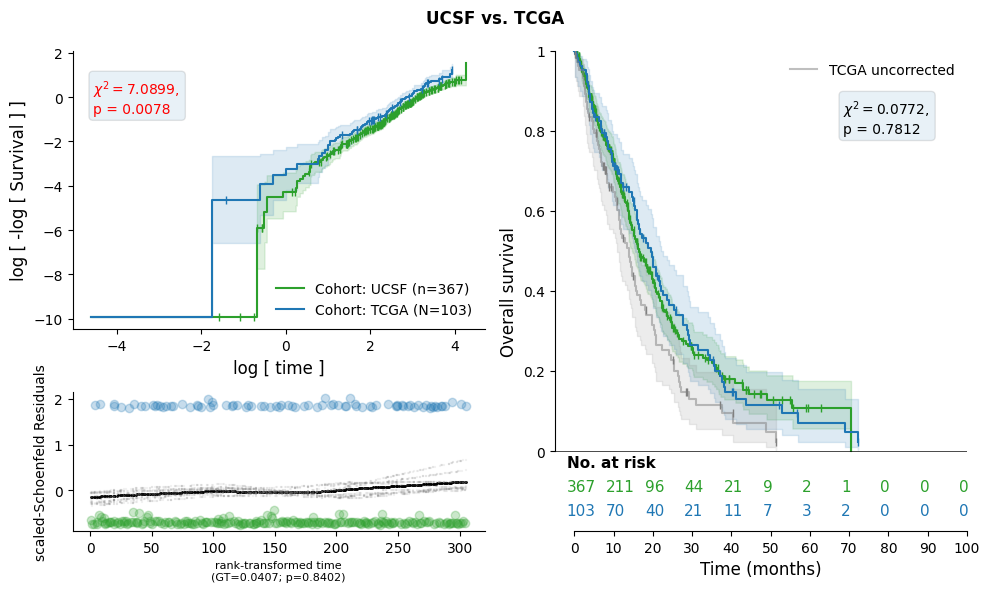

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UCSF vs. RHUH


100%|██████████| 1000/1000 [00:14<00:00, 68.62it/s]


C-index = 0.5047244251782896 (p=0.621)
Log HR = [0.29224262]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        1.902822  0.167763  2.575505
       km              2.040125  0.153197  2.706539
       log             3.436208  0.063782  3.970708
       rank            2.265548  0.132279  2.918340


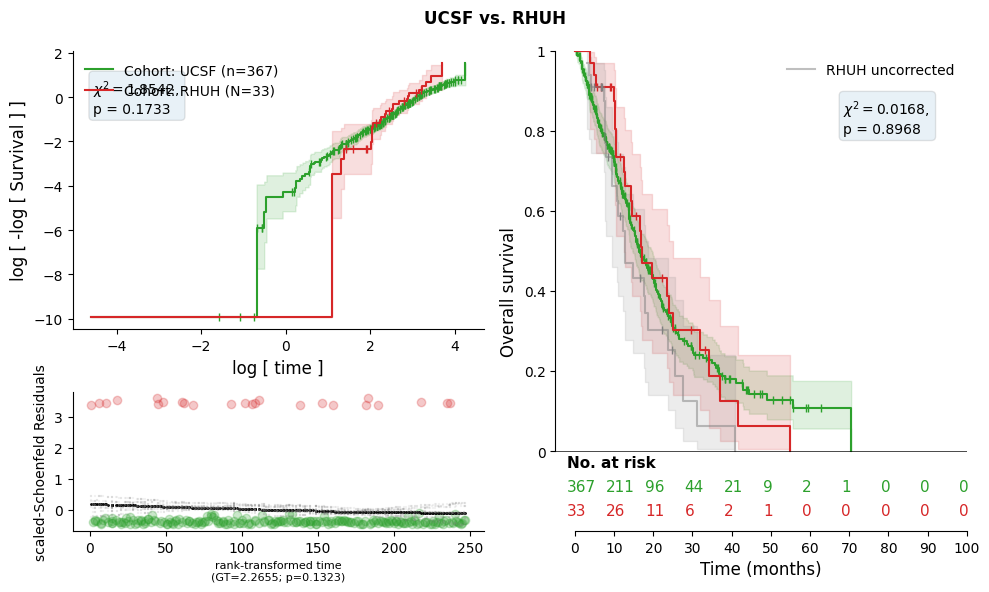

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UCSF vs. LUMIERE


100%|██████████| 1000/1000 [00:14<00:00, 66.83it/s]


C-index = 0.49590755897929706 (p=0.957)
Log HR = [0.2332381]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        9.741587  0.001801  9.116623
       km             10.358303  0.001289  9.599604
       log             7.852540  0.005075  7.622395
       rank           10.016235  0.001552  9.331969


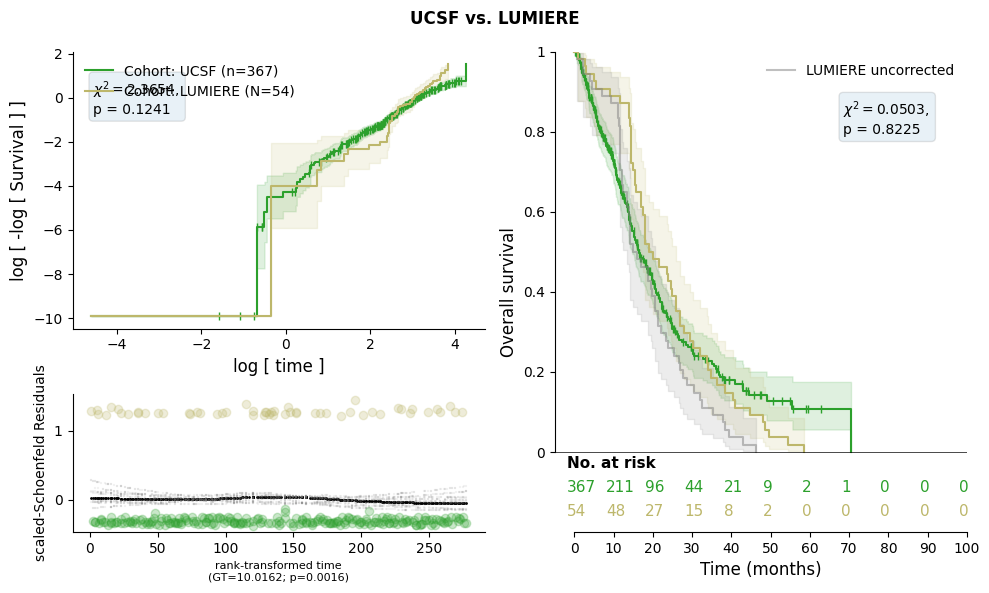

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UPENN vs. TCGA


100%|██████████| 1000/1000 [00:24<00:00, 40.35it/s]


C-index = 0.5024958111240199 (p=0.7)
Log HR = [0.05157669]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        0.130099  0.718329  0.477283
       km              0.045743  0.830644  0.267697
       log             0.002447  0.960543  0.058078
       rank            0.048152  0.826311  0.275243


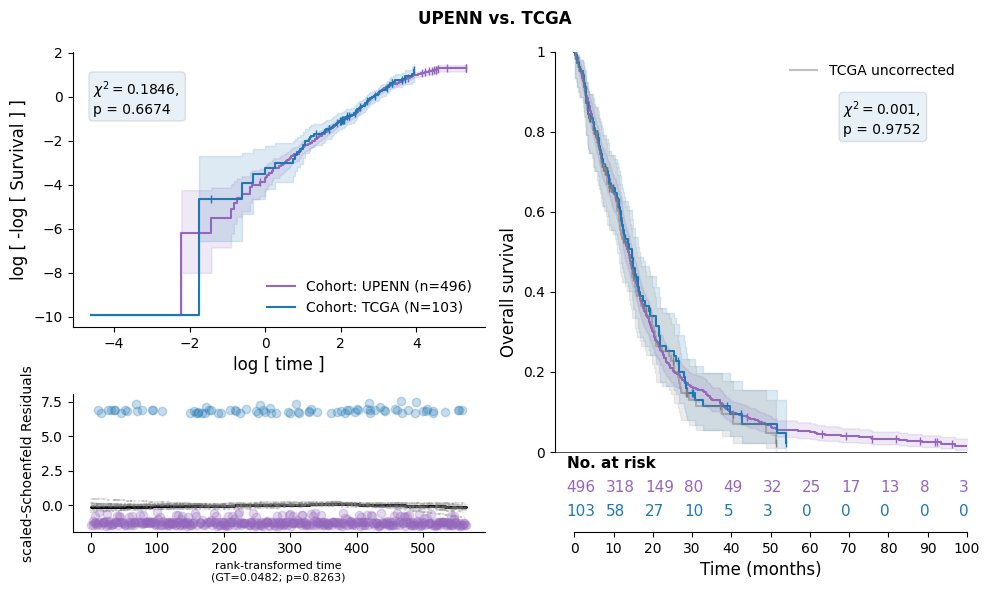

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UPENN vs. RHUH


100%|██████████| 1000/1000 [00:22<00:00, 44.48it/s]


C-index = 0.5040267912405317 (p=0.477)
Log HR = [-0.0096247]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        1.007350  0.315538  1.664112
       km              2.006182  0.156659  2.674299
       log             3.226622  0.072450  3.786871
       rank            2.045321  0.152675  2.711466


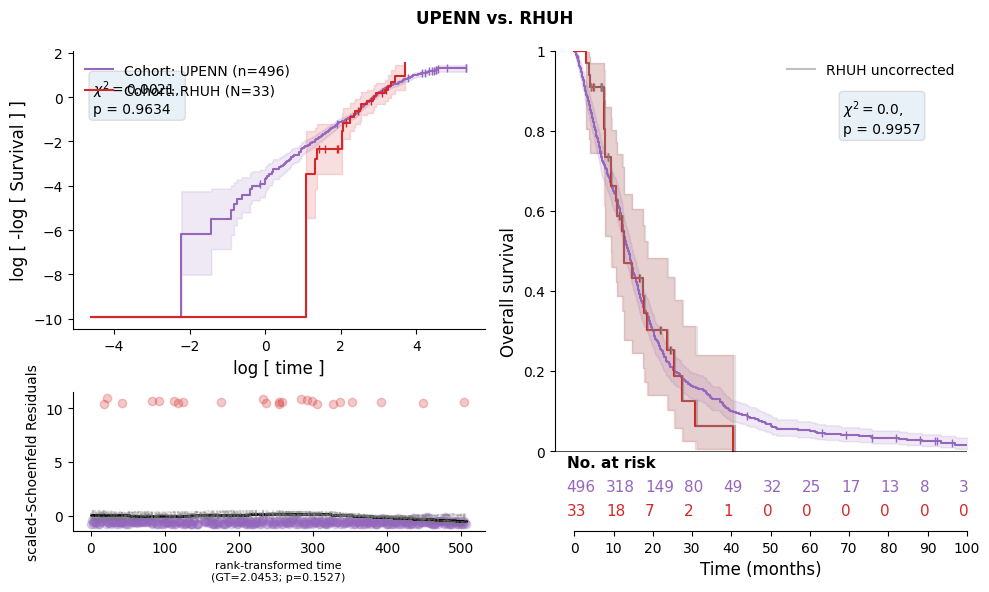

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
UPENN vs. LUMIERE


100%|██████████| 1000/1000 [00:22<00:00, 43.75it/s]


C-index = 0.5134441097701878 (p=0.073)
Log HR = [-0.04127113]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        6.463085  0.011014  6.504540
       km             10.296332  0.001333  9.551163
       log             8.344990  0.003868  8.014375
       rank           10.266853  0.001354  9.528113


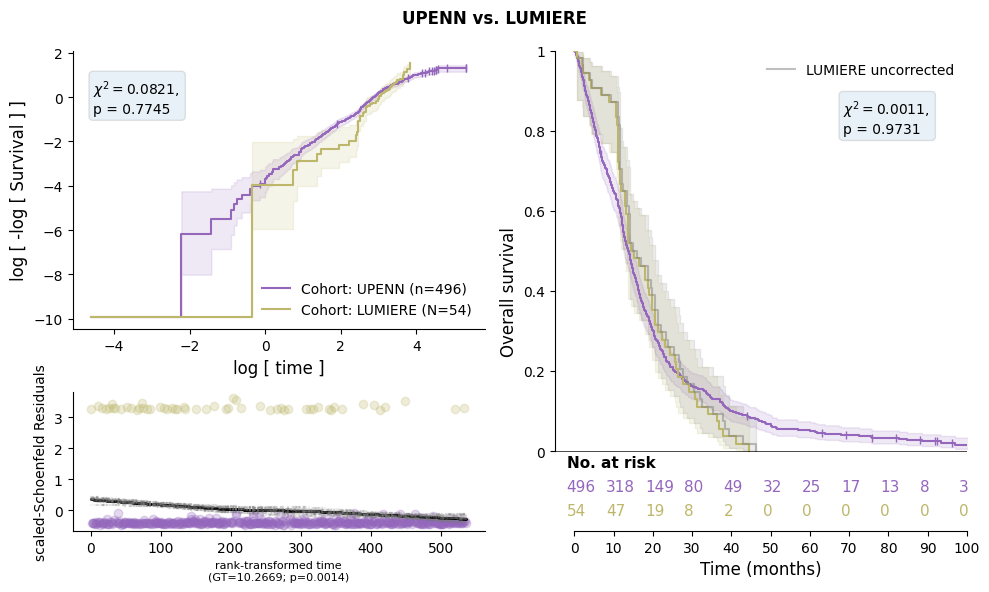

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
TCGA vs. RHUH


100%|██████████| 1000/1000 [00:06<00:00, 156.78it/s]


C-index = 0.5214454811307617 (p=0.414)
Log HR = [-0.04621158]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        1.421279  0.233193  2.100404
       km              1.759360  0.184704  2.436710
       log             2.948977  0.085932  3.540662
       rank            1.908891  0.167087  2.581333


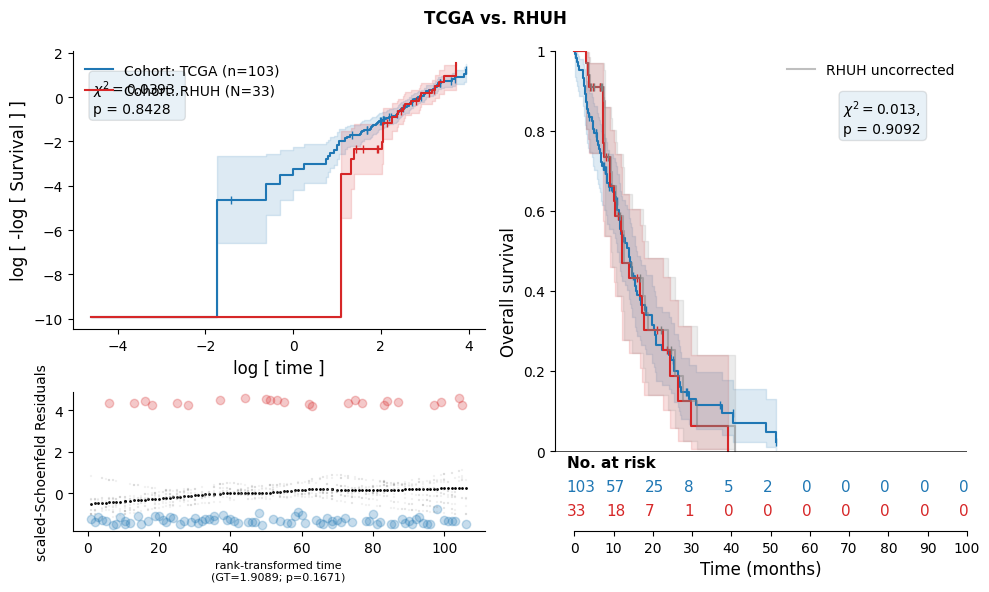

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
TCGA vs. LUMIERE


100%|██████████| 1000/1000 [00:07<00:00, 139.95it/s]


C-index = 0.5466787209744957 (p=0.046)
Log HR = [-0.11320962]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        7.600167  0.005836  7.420733
       km              7.816529  0.005177  7.593653
       log             6.250704  0.012414  6.331842
       rank            7.467009  0.006284  7.314104


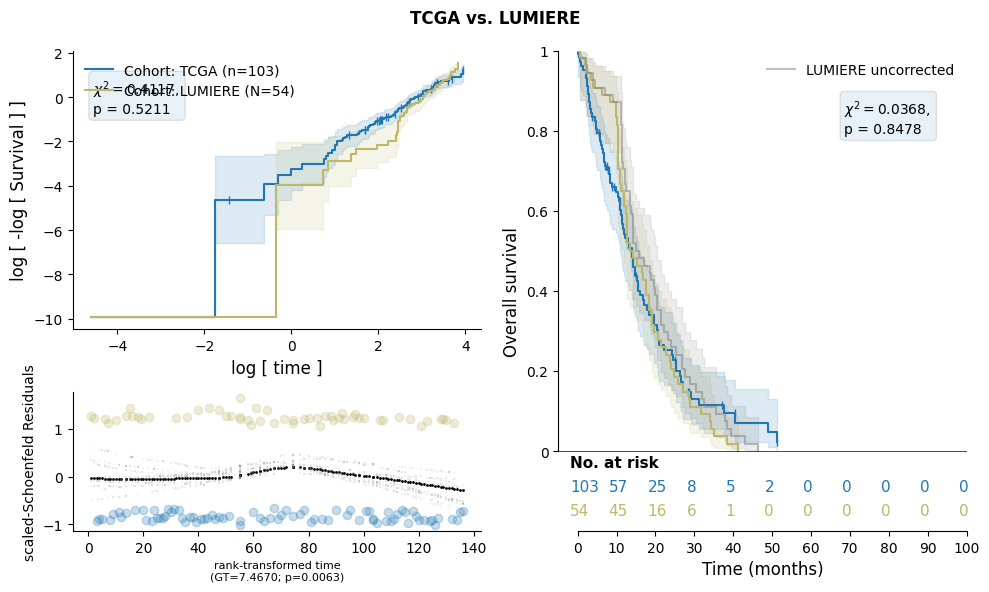

++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++
RHUH vs. LUMIERE


100%|██████████| 1000/1000 [00:04<00:00, 235.04it/s]


C-index = 0.5357809583074051 (p=0.257)
Log HR = [-0.21704421]

Results form the Grambsch-Therneau test:
                 test_statistic         p  -log2(p)
cohort identity        0.211614  0.645505  0.631499
       km              0.826031  0.363423  1.460280
       log             0.036857  0.847757  0.238278
       rank            0.741638  0.389137  1.361651


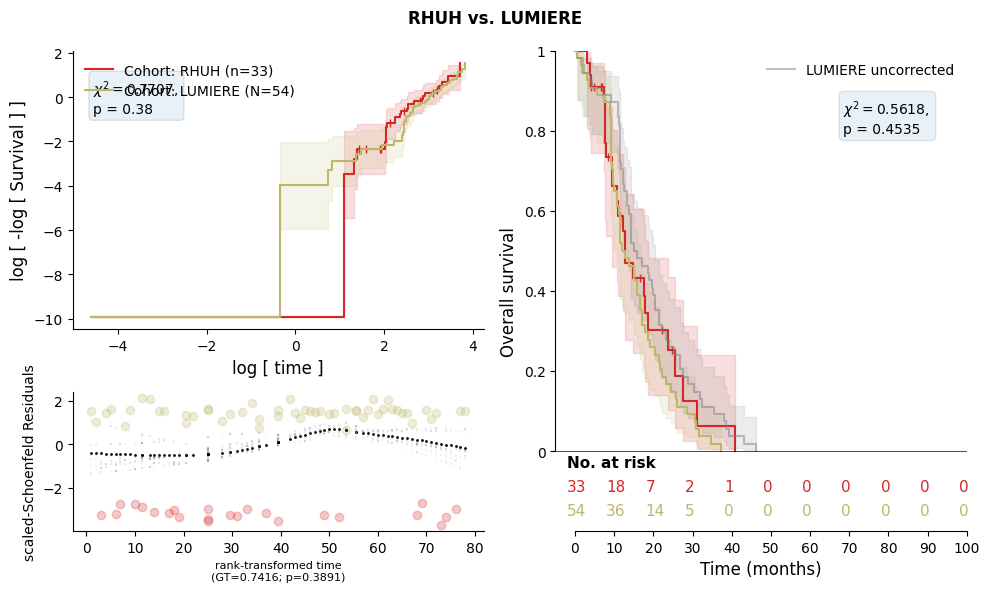

++++++++++++++++++++++++++++++++++++++++


In [28]:
import itertools

for i,j in itertools.combinations(cohort_ids, 2):
    inspect_survival_diffs_in_paired_cohorts(
        full_data=hcpex,
        cohorts=[i,j],
        RESULTS=RESULTS,
        name_cohort=name_cohort,
        duration_col="OS (days)",
        status_col="status",
        daysXmonth=daysXmonth,
        months=range(0,110,10), 
        n_perms=1000, 
        eps_=0.01,
        show_plot=True
    )

## SITES instead of cohorts

This remains to be done!!!!!

100%|██████████| 1000/1000 [00:37<00:00, 26.43it/s]


C-index = 0.5317889078460699 (p=0.0)
Log HR = [0.29214549]
               test_statistic         p  -log2(p)
site identity        0.037322  0.846810  0.239889
     km              0.000088  0.992513  0.010842
     log             0.032067  0.857880  0.221152
     rank            0.000939  0.975556  0.035703


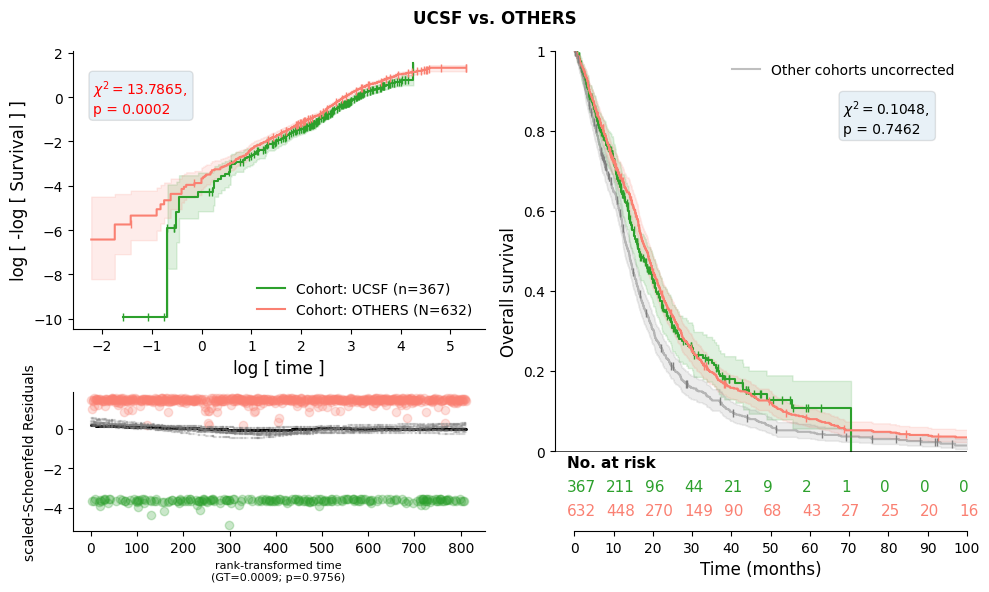

In [29]:
sites = [0,1]

# Pre-correction
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1]) 
ax1 = plt.subplot(gs[0, 0]) 
ax2 = plt.subplot(gs[:, 1])
ax3 = plt.subplot(gs[1, 0])
colors = ["tab:green", "salmon"]
OS_STATS = []
GROUP_STATS = []
nums = np.empty(shape=(2,), dtype=object)
for i, site in enumerate(sites):
    diag = hcpex[hcpex["site"]==site]
    mask = ~np.isnan(diag["status"]) & ~np.isnan(diag["OS (days)"])
    diag = diag[mask]
    nums[i] = []
    for t in months:
        nums[i].append((diag["OS (days)"]>=(t*daysXmonth)).sum())
    time, survival_prob, conf_int = kaplan_meier_estimator(
                diag["status"]==1, diag["OS (days)"], conf_type="log-log"
            )
    ax1.step(np.log(eps_+time/daysXmonth), np.log(eps_-np.log(eps_+survival_prob)), where="post", label=f"Cohort: UCSF (n={all_ucsf})" if site==0 else f"Cohort: OTHERS (N={all_upenn+all_tcga+all_rhuh})", color=colors[i])
    ax1.fill_between(np.log(eps_+time/daysXmonth), np.log(eps_-np.log(eps_+conf_int[0])), np.log(eps_-np.log(eps_+conf_int[1])), alpha=0.15, step="post", color=colors[i])
    for t in diag.loc[diag["status"]==0, "OS (days)"].values: # Censoring times
        ax1.plot(np.log(eps_+time[time==t]/daysXmonth), np.log(eps_-np.log(eps_+survival_prob[time==t])), "|", color=colors[i])
    OS_STATS.extend([(st, ovs) for st, ovs in zip(diag["status"]==1, diag["OS (days)"].values)])
    GROUP_STATS.extend([i+1 for ovs in diag["OS (days)"].values])
OS_STATS = np.array(OS_STATS, dtype=[('event', 'bool'),('time', 'float')])
chisquared, p_val, stats, covariance = compare_survival(OS_STATS, GROUP_STATS, return_stats=True)
ax1.text(0.05, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax1.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")        
ax1.set_xlabel("log [ time ]", fontsize=12)
ax1.set_ylabel("log [ -log [ Survival ] ]", fontsize=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)

# Fit the model to estimate the site-effect
Cmodel = CoxPHSurvivalAnalysis(n_iter=200)
mask = ~np.isnan(hcpex["status"]) & ~np.isnan(hcpex["OS (days)"])
Cmodel.fit(hcpex.loc[mask, "site"].values.reshape(-1,1), OS_STATS)
c_index = Cmodel.score(hcpex.loc[mask, "site"].values.reshape(-1,1), OS_STATS)
pop = []
for perm_i in tqdm(range(n_perms)):#
    perm_OS_STATS = np.random.permutation(OS_STATS)
    p_Cmodel = CoxPHSurvivalAnalysis()
    p_Cmodel.fit(hcpex.loc[mask, "site"].values.reshape(-1, 1), perm_OS_STATS)
    pop.append(p_Cmodel.score(hcpex.loc[mask, "site"].values.reshape(-1, 1), perm_OS_STATS))
p_value = np.mean(np.array(pop) >= c_index)
print(f"C-index = {c_index} (p={p_value})")
print(f"Log HR = {Cmodel.coef_}")
logHR_site = Cmodel.coef_[0]

# Plot Schoenfeld residuals
lifelines_model = CoxPHFitter()
data = hcpex[["site", "OS (days)", "status"]].dropna()
lifelines_model.fit(data, duration_col="OS (days)", event_col="status")
test = proportional_hazard_test(lifelines_model, data, time_transform="all") #Grambsch-Therneau Test
print(test.summary)
rank_stat, p_val_GT = test.test_statistic[0], test.p_value[0]
schoenfeld_residuals = lifelines_model.compute_residuals(data, kind='scaled_schoenfeld')
site_schoenfeld_residuals = schoenfeld_residuals['site'].values
tt = data.loc[data['status']==1, 'OS (days)'].rank()
ax3.scatter(tt[site_schoenfeld_residuals>0], site_schoenfeld_residuals[site_schoenfeld_residuals>0], color=colors[1], alpha=0.25)
ax3.scatter(tt[site_schoenfeld_residuals<0], site_schoenfeld_residuals[site_schoenfeld_residuals<0], color=colors[0], alpha=0.25)
y_lowess = lowess(tt.values, site_schoenfeld_residuals)
ax3.scatter(tt.values, y_lowess, color="k", alpha=1.0, s=1)
for _ in range(10):
    ix = sorted(np.random.choice(tt.shape[0], tt.shape[0]))
    tt_ = tt.values[ix]
    y_lowess = lowess(tt_, site_schoenfeld_residuals[ix])
    ax3.scatter(tt_, y_lowess, color="gray", alpha=0.10, s=2, marker="+")
ax3.set_xlabel(f"rank-transformed time\n(GT={rank_stat:.4f}; p={p_val_GT:.4f})", fontsize=8)
ax3.set_ylabel("scaled-Schoenfeld Residuals", fontsize=10)
ax3.spines[["top", "right"]].set_visible(False)

# Post-correction
OS_STATS_deSITE = []
GROUP_STATS = []
nums = np.empty(shape=(2,), dtype=object)
for i, site in enumerate(sites):
    diag = hcpex[hcpex["site"]==site]
    mask = ~np.isnan(diag["status"]) & ~np.isnan(diag["OS (days)"])
    diag = diag[mask]
    diag["OS (days)"] = diag["OS (days)"] * np.exp(Cmodel.coef_[0]*site)
    nums[i] = []
    for t in months:
        nums[i].append((diag["OS (days)"]>=(t*daysXmonth)).sum())
    
    time, survival_prob, conf_int = kaplan_meier_estimator(
                diag["status"]==1, diag["OS (days)"], conf_type="log-log"
            )
    ax2.step(time/daysXmonth, survival_prob, where="post", color=colors[i])
    ax2.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.15, step="post", color=colors[i])
    for t in diag.loc[diag["status"]==0, "OS (days)"].values: # Censoring times
        ax2.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color=colors[i])

    OS_STATS_deSITE.extend([(st, ovs) for st, ovs in zip(diag["status"]==1, diag["OS (days)"].values)])
    GROUP_STATS.extend([i+1 for ovs in diag["OS (days)"].values])

OS_STATS_deSITE = np.array(OS_STATS_deSITE, dtype=[('event', 'bool'),('time', 'float')])
chisquared, p_val, stats, covariance = compare_survival(OS_STATS_deSITE, GROUP_STATS, return_stats=True)
ax2.text(0.70, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax2.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")        

# Plotting the uncorrected data
diag = hcpex[hcpex["site"]==1]
mask = ~np.isnan(diag["status"]) & ~np.isnan(diag["OS (days)"])
diag = diag[mask]
for t in months:
    nums[i].append((diag["OS (days)"]>=(t*daysXmonth)).sum())
time, survival_prob, conf_int = kaplan_meier_estimator(
            diag["status"]==1, diag["OS (days)"], conf_type="log-log"
        )
ax2.step(time/daysXmonth, survival_prob, where="post", color="gray", alpha=0.5, label="Other cohorts uncorrected")
ax2.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.15, step="post", color="gray")
for t in diag.loc[diag["status"]==0, "OS (days)"].values: # Censoring times
    ax2.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color="gray")

for i,t in enumerate(months):
    ax2.text(t-2, -0.07, f"{nums[0][i]}", transform=ax2.transData, fontsize=11, verticalalignment='top', color=colors[0]) 
    ax2.text(t-2, -0.13, f"{nums[1][i]}", transform=ax2.transData, fontsize=11, verticalalignment='top', color=colors[1]) 
ax2.text(-2, -0.01, "No. at risk", transform=ax2.transData, fontsize=11, verticalalignment='top', color="black", fontweight='bold') 
ax2.hlines(0,-5,months[-1]+5, color="black", linewidth=.5)
ax2.set_ylim([-.2,1])
ax2.set_xlim([-5,75])
ax2.set_xticks(range(0,months[-1]+10,10))
ax2.set_xticklabels(range(0,months[-1]+10,10))
ax2.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
ax2.spines['left'].set_bounds(0,1)
ax2.spines['bottom'].set_bounds(0,months[-1])
ax2.set_xlabel("Time (months)", fontsize=12)
ax2.set_ylabel("Overall survival", fontsize=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(frameon=False)

fig.suptitle("UCSF vs. OTHERS", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{RESULTS}/OS-stats/Site-effects_Survival-times.pdf", dpi=200, format="pdf")
fig.savefig(f"{RESULTS}/OS-stats/Site-effects_Survival-times.svg", dpi=200, format="svg")

In [30]:
# Apply the correction
hcpex["OS (days) - corrected"] = hcpex["OS (days)"] * np.exp(logHR_site * hcpex["site"])
aal3["OS (days) - corrected"] = aal3["OS (days)"] * np.exp(logHR_site * aal3["site"])

In [31]:
# Save 
hcpex.to_csv(f"{RESULTS}/data-clinical_parcellation-hcpex_4-cohorts.csv", sep=",", index=False)
hcpex.to_csv(f"{RESULTS}/data-clinical_parcellation-hcpex_4-cohorts.tsv", sep="\t", index=False)

aal3.to_csv(f"{RESULTS}/data-clinical_parcellation-aal3_4-cohorts.csv", sep=",", index=False)
aal3.to_csv(f"{RESULTS}/data-clinical_parcellation-aal3_4-cohorts.tsv", sep="\t", index=False)

import json
with open(f"{RESULTS}/keys-maps.json", 'w') as f:
    json.dump(
        {
            "Sex": {"Male": 0, "Female": 1},
            "Extent of Resection": {"Biopsy": 0, "Subtotal (<90%)": 1, "Gross total (>= 90%)": 2, "Not Available": "np.nan"},
            "MGMT Promoter": {"Unmethylated/Negative": 0, "Intermediate": 1, "Methylated/Positive": 2, "Not Available": "np.nan"}
        }, f, indent=4
    )

Cohorts UCSF and UPENN: chi-squared of 0.111 with p-value of 0.739 (two-sided log-rank test)
Cohorts UCSF and TCGA: chi-squared of 0.0707 with p-value of 0.7903 (two-sided log-rank test)
Cohorts UCSF and RHUH: chi-squared of 0.0168 with p-value of 0.8968 (two-sided log-rank test)
Cohorts UPENN and TCGA: chi-squared of 0.1846 with p-value of 0.6674 (two-sided log-rank test)
Cohorts UPENN and RHUH: chi-squared of 0.0021 with p-value of 0.9634 (two-sided log-rank test)
Cohorts TCGA and RHUH: chi-squared of 0.0393 with p-value of 0.8428 (two-sided log-rank test)


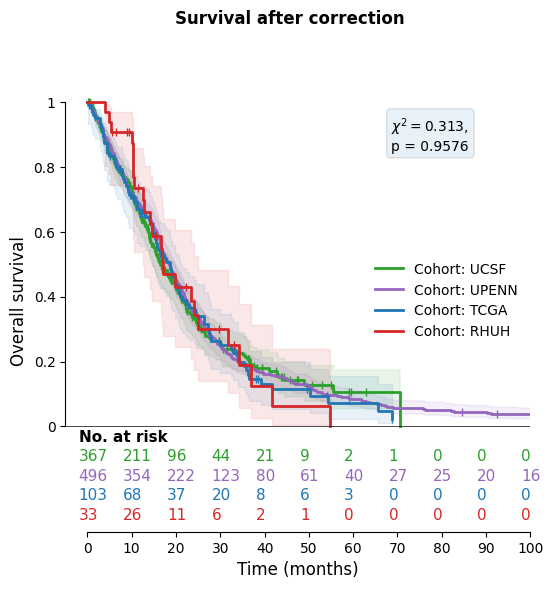

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

months = range(0,110,10)
cohort_ids = [0,1,2,3]
colors = ["tab:green", "tab:purple", "tab:blue","tab:red"]
cohort_name = ["UCSF", "UPENN", "TCGA", "RHUH"]
OS_STATS_deSITE = []
GROUP_STATS = []

nums = np.empty(shape=(4,), dtype=object)
for i, cohort in enumerate(cohort_ids):
    diag = hcpex[hcpex["cohort"]==cohort]
    mask = ~np.isnan(diag["status"]) & ~np.isnan(diag["OS (days) - corrected"])
    diag = diag[mask]

    nums[i] = []
    for t in months:
        nums[i].append((diag["OS (days) - corrected"]>=(t*daysXmonth)).sum())
    
    time, survival_prob, conf_int = kaplan_meier_estimator(
                diag["status"]==1, diag["OS (days) - corrected"], conf_type="log-log"
            )
    time = np.insert(time, 0, 0)
    survival_prob = np.insert(survival_prob, 0, 1)
    conf_int = np.insert(conf_int, 0, 1, axis=1)
    ax.step(time/daysXmonth, survival_prob, where="post", color=colors[i], label=f"Cohort: {cohort_name[i]}", linewidth=2)
    ax.fill_between(time/daysXmonth, conf_int[0], conf_int[1], alpha=0.10, step="post", color=colors[i])
    for t in diag.loc[diag["status"]==0, "OS (days) - corrected"].values: # Censoring times
        ax.plot(time[time==t]/daysXmonth, survival_prob[time==t], "|", color=colors[i])

    OS_STATS_deSITE.extend([(st, ovs) for st, ovs in zip(diag["status"]==1, diag["OS (days) - corrected"].values)])
    GROUP_STATS.extend([i+1 for ovs in diag["OS (days) - corrected"].values])

OS_STATS_deSITE = np.array(OS_STATS_deSITE, dtype=[('event', 'bool'),('time', 'float')])
chisquared, p_val, stats, covariance = compare_survival(OS_STATS_deSITE, GROUP_STATS, return_stats=True)
ax.text(0.70, 0.90, r"$\chi^2 =$"+f"{round(chisquared,4)}, \np = {round(p_val,4)}", transform=ax.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1), color="red" if p_val<=0.05 else "black")    

for i,t in enumerate(months):
    ax.text(t-2, -0.07, f"{nums[0][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[0]) 
    ax.text(t-2, -0.13, f"{nums[1][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[1]) 
    ax.text(t-2, -0.19, f"{nums[2][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[2]) 
    ax.text(t-2, -0.25, f"{nums[3][i]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[3]) 
ax.text(-2, -0.01, "No. at risk", transform=ax.transData, fontsize=11, verticalalignment='top', color="black", fontweight='bold') 
ax.hlines(0,-5,months[-1]+5, color="black", linewidth=.5)
ax.set_ylim([-.325,1.1])
ax.set_xlim([-5,75])
ax.set_xticks(range(0,months[-1]+10,10))
ax.set_xticklabels(range(0,months[-1]+10,10))
ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
ax.spines['left'].set_bounds(0,1)
ax.spines['bottom'].set_bounds(0,months[-1])
ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Overall survival", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.suptitle("Survival after correction", fontweight="bold")
fig.savefig(f"{RESULTS}/OS-stats/OS-cohorts_after-correction.pdf", dpi=200, format="pdf")
fig.savefig(f"{RESULTS}/OS-stats/OS-cohorts_after-correction.svg", dpi=200, format="svg")

GROUP_STATS_array = np.array(GROUP_STATS)
chisquared, p_val = np.zeros((len(cohort_ids), len(cohort_ids))), np.zeros((len(cohort_ids), len(cohort_ids)))
name_cohort = {0: "UCSF", 1: "UPENN", 2: "TCGA", 3: "RHUH"}

for i, cohort_i in enumerate(cohort_ids):
    for j in range(i+1, len(cohort_ids)):
        cohort_j = cohort_ids[j]

        chisquared[i,j], p_val[i,j] = compare_survival(
            OS_STATS_deSITE[(GROUP_STATS_array==cohort_i+1) | (GROUP_STATS_array==cohort_j+1)], 
            list(GROUP_STATS_array[(GROUP_STATS_array==cohort_i+1) | (GROUP_STATS_array==cohort_j+1)]), 
            return_stats=False
        )
        if p_val[i,j]<=0.05:
            print(f"ATENTION!!\n------>\t Cohorts {name_cohort[i]} and {name_cohort[j]}: chi-squared of {chisquared[i,j].round(4)} with p-value of {p_val[i,j].round(4)} (two-sided log-rank test)")
        else: 
            print(f"Cohorts {name_cohort[i]} and {name_cohort[j]}: chi-squared of {chisquared[i,j].round(4)} with p-value of {p_val[i,j].round(4)} (two-sided log-rank test)")
